<a href="https://colab.research.google.com/github/karolinajapinska/E-commerce_accountdynamic-analysis/blob/main/Portfolio_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A/B Testing Statistical Significance Analysis

## 1. Project Overview

The objective of this project is to evaluate A/B test performance using statistical methods implemented in Python and visualize the results in Tableau.

Unlike traditional approaches that rely on online A/B testing calculators, this project builds a reusable Python framework capable of calculating statistical significance for multiple conversion metrics automatically.

This project demonstrates an end-to-end A/B testing analysis workflow using Python, BigQuery and Tableau.

The final output is a structured dataset containing conversion rates, uplift, z-statistics, p-values and significance flags, which is then visualized in Tableau through an interactive dashboard.

# 2. Project Workflow

The project consists of two major stages:

## Stage 1 – Statistical Significance Analysis in Python
* Data extraction from BigQuery
* Data quality validation
* Conversion rate calculation
* Statistical significance testing
* Export of final results dataset
## Stage 2 – Tableau Dashboard Development
* Dashboard redesign
* Visualization of conversion metrics
* Statistical significance indicators
* Interactive filtering
* Business interpretation

#3. Statistical Methodology
Hypothesis Testing

For each conversion metric the following hypotheses are tested:

Null Hypothesis (H₀)

The conversion rate of the Variant group is equal to the conversion rate of the Control group.

Alternative Hypothesis (H₁)

The conversion rate of the Variant group differs from the conversion rate of the Control group.
#4. Statistical Test

Since all analyzed metrics are binary variables (0/1), a Two-Proportion Z-Test is used.

The test compares conversion rates between:

Control Group
Variant Group

The significance threshold is:

α = 0.05

If:

p-value < 0.05

the result is considered statistically significant.
# STAGE 1
# 5. Data Extraction from BigQuery (SQL)

## 5.1 Data Model Overview

A consolidated session-level dataset is created by joining multiple tables:
* session → base table (all sessions)
* ab_test → A/B test assignment and test groups
* session_params → device, geography and traffic data
* event_params → conversion events
* account_session → new account creation data

### Key Design Decisions

* Use session as the base table to preserve all sessions
* Use LEFT JOINs to retain sessions without conversion events
* Create binary indicators for conversion events (0/1)
* Include both test and control groups
* Build one row per session for statistical analysis

### Conversion Metrics

The following metrics are calculated:
* add_payment_info / session
* add_shipping_info / session
* begin_checkout / session
* new_account / session

## 5.2 Import Libraries

In [ ]:
import pandas as pd
import numpy as np

from google.cloud import bigquery
from google.colab import auth

from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns



## 5.3 Final SQL Query and Extraction in Python

In [ ]:
# Authentication
auth.authenticate_user()

# Creating a BigQuery client
client = bigquery.Client(project="data-analytics-mate")

# SQL query
query ="""
-- Final dataset for A/B testing analysis
-- Grain: one row = one session
WITH sessions AS (

SELECT
    s.ga_session_id,
    ab.test,
    ab.test_group,
    sp.country,
    sp.continent,
    sp.device,
    sp.channel
FROM `DA.session` s
JOIN `DA.ab_test` ab
    ON s.ga_session_id = ab.ga_session_id
LEFT JOIN `DA.session_params` sp
    ON s.ga_session_id = sp.ga_session_id
),

event_metrics AS (
SELECT
    ga_session_id,
    COUNTIF(event_name = 'add_payment_info') > 0 AS add_payment_info,
    COUNTIF(event_name = 'add_shipping_info') > 0 AS add_shipping_info,
    COUNTIF(event_name = 'begin_checkout') > 0 AS begin_checkout
  FROM `DA.event_params`
  WHERE event_name IN (
    'add_payment_info',
    'add_shipping_info',
    'begin_checkout'
  )
GROUP BY ga_session_id
),

new_accounts AS (
SELECT DISTINCT
    ga_session_id,
    1 AS new_account
FROM `DA.account_session`
)
SELECT
    s.*,
  IFNULL(CAST(e.add_payment_info AS INT64), 0)  AS add_payment_info,
  IFNULL(CAST(e.add_shipping_info AS INT64), 0) AS add_shipping_info,
  IFNULL(CAST(e.begin_checkout AS INT64), 0)    AS begin_checkout,
  IFNULL(CAST(n.new_account AS INT64), 0)       AS new_account
FROM sessions s
LEFT JOIN event_metrics e
    ON s.ga_session_id=e.ga_session_id
LEFT JOIN new_accounts n
    ON s.ga_session_id=n.ga_session_id"""

# Executing the query
query_job = client.query(query)  # Executing the SQL query
results = query_job.result()  # Waiting for the query to complete

# Converting the results to a DataFrame
df = results.to_dataframe()

# Displaying the result
df.head()

,ga_session_id,test,test_group,country,continent,device,channel,add_payment_info,add_shipping_info,begin_checkout,new_account
0,7315441184,2,1,United States,Americas,mobile,Direct,0,1,1,0
1,7315441184,1,2,United States,Americas,mobile,Direct,0,1,1,0
2,6756024801,2,2,Japan,Asia,mobile,Undefined,1,1,1,0
3,6756024801,1,2,Japan,Asia,mobile,Undefined,1,1,1,0
4,8523271383,2,2,India,Asia,desktop,Undefined,1,1,1,0


## 5.4. Data quality check

Before calculating statistical significance, I checked the dataset structure, missing/duplicate values and available A/B test/test groups.

In [ ]:
print("DATASET OVERVIEW")
print("-" * 50)

# Dataset structure
df.info()

print("\nDATASET DIMENSIONS")
print("-" * 50)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Basic descriptive statistics
print("\nDESCRIPTIVE STATISTICS")
print("-" * 50)
display(df.describe(include='all'))

# MISSING VALUES
print("\nMISSING VALUES (%)")
print("-" * 50)

missing_values = (
    df.isna()
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

display(missing_values)

# AVAILABLE TESTS
print("\nAVAILABLE TESTS")
print("-" * 50)

display(
    df['test']
    .value_counts()
    .reset_index()
    .rename(columns={'index':'test_name',
                     'test':'sessions'})
)
# AVAILABLE TEST GROUPS
print("\nAVAILABLE TEST GROUPS")
print("-" * 50)

display(
    df[['test', 'test_group']]
    .drop_duplicates()
    .sort_values(['test', 'test_group'])
)

# Number of sessions in each group
print("\nSESSIONS BY TEST GROUP")
print("-" * 50)

display(
    df.groupby(['test', 'test_group'])
      .size()
      .reset_index(name='sessions')
)

# DUPLICATE RECORDS
print("\nDUPLICATE RECORDS")
print("-" * 50)

duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    display(df[df.duplicated()].head())

#  DUPLICATE SESSION IDs
print("\nDUPLICATE SESSION IDs")
print("-" * 50)

duplicate_sessions = df['ga_session_id'].duplicated().sum()

print(f"Duplicated session IDs: {duplicate_sessions}")

#UNIQUE VALUES CHECK
print("\nUNIQUE VALUES IN KEY COLUMNS")
print("-" * 50)

for col in ['test', 'test_group']:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].unique())
    print()

DATASET OVERVIEW
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542142 entries, 0 to 542141
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   ga_session_id      542142 non-null  Int64 
 1   test               542142 non-null  Int64 
 2   test_group         542142 non-null  Int64 
 3   country            542142 non-null  object
 4   continent          542142 non-null  object
 5   device             542142 non-null  object
 6   channel            542142 non-null  object
 7   add_payment_info   542142 non-null  Int64 
 8   add_shipping_info  542142 non-null  Int64 
 9   begin_checkout     542142 non-null  Int64 
 10  new_account        542142 non-null  Int64 
dtypes: Int64(7), object(4)
memory usage: 49.1+ MB

DATASET DIMENSIONS
--------------------------------------------------
Rows: 542142
Columns: 11

DESCRIPTIVE STATISTICS
--------------------------

,ga_session_id,test,test_group,country,continent,device,channel,add_payment_info,add_shipping_info,begin_checkout,new_account
count,542142.0,542142.0,542142.0,542142,542142,542142,542142,542142.0,542142.0,542142.0,542142.0
unique,<NA>,<NA>,<NA>,108,6,3,5,<NA>,<NA>,<NA>,<NA>
top,<NA>,<NA>,<NA>,United States,Americas,desktop,Organic Search,<NA>,<NA>,<NA>,<NA>
freq,<NA>,<NA>,<NA>,237780,299372,317230,191704,<NA>,<NA>,<NA>,<NA>
mean,4992171099.022109,2.867616,1.4999,NaN,NaN,NaN,NaN,0.021061,0.035625,0.035631,0.083377
std,2888274921.78916,1.106545,0.5,NaN,NaN,NaN,NaN,0.143588,0.185354,0.185368,0.276451
min,6412.0,1.0,1.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
25%,2492727194.0,2.0,1.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
50%,4987837668.5,3.0,1.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
75%,7491417142.0,4.0,2.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0



MISSING VALUES (%)
--------------------------------------------------


,0
ga_session_id,0.0
test,0.0
test_group,0.0
country,0.0
continent,0.0
device,0.0
channel,0.0
add_payment_info,0.0
add_shipping_info,0.0
begin_checkout,0.0



AVAILABLE TESTS
--------------------------------------------------


...


AVAILABLE TEST GROUPS
--------------------------------------------------


,test,test_group
9,1,1
1,1,2
0,2,1
2,2,2
86,3,1
89,3,2
191,4,1
189,4,2



SESSIONS BY TEST GROUP
--------------------------------------------------


,test,test_group,sessions
0,1,1,45362
1,1,2,45193
2,2,1,50637
3,2,2,50244
4,3,1,70047
5,3,2,70439
6,4,1,105079
7,4,2,105141



DUPLICATE RECORDS
--------------------------------------------------
Number of duplicate rows: 0

DUPLICATE SESSION IDs
--------------------------------------------------
Duplicated session IDs: 207561

UNIQUE VALUES IN KEY COLUMNS
--------------------------------------------------
test: 4 unique values
<IntegerArray>
[2, 1, 3, 4]
Length: 4, dtype: Int64

test_group: 2 unique values
<IntegerArray>
[1, 2]
Length: 2, dtype: Int64



##5.5 Conversion Rate Calculation
The following conversion metrics were analyzed:

* add_payment_info
* add_shipping_info
* begin_checkout
* new_account

Conversion Rate Formula:

CR = Conversions / Sessions

For every test and metric, the following values were calculated:

* Number of conversions
* Number of sessions
* Conversion rate

The calculations were implemented dynamically using loops to support any number of metrics.

##5.6 Uplift Calculation

The relative difference between Variant and Control was calculated using:

Uplift (%) = ((CR Variant − CR Control) / CR Control) × 100

Positive values indicate performance improvement.

Negative values indicate performance deterioration.

##5.7 Statistical Significance Calculation

The Python script automatically calculates:

* Z Statistic
* P-value
* Statistical Significance Flag

Output columns:

* metric_change
* z_stat
* p_value
* significant

This structure allows direct integration with Tableau.
##5.8 Final Output Dataset

The final Excel file contains:

* test_number
* metric
* numerator_cc
* denominator_cc
* conversion_rate_variant
* numerator_co
* denominator_co
* conversion_rate_control
* metric_change
* z_stat
* p_value
* significant

The file serves as the primary data source for Tableau

In [ ]:
metrics = [
    'add_payment_info',
    'add_shipping_info',
    'begin_checkout',
    'new_account'
]

results = []

for test_id in df['test'].unique():

    test_df = df[df['test'] == test_id]

    control = test_df[test_df['test_group'] == 1]
    variant = test_df[test_df['test_group'] == 2]

    for metric in metrics:

        numerator_cc = variant[metric].sum()
        denominator_cc = len(variant)

        numerator_co = control[metric].sum()
        denominator_co = len(control)

        conversion_rate_variant = numerator_cc / denominator_cc
        conversion_rate_control = numerator_co / denominator_co

         # uplift (%)
        metric_change = (
            (conversion_rate_variant - conversion_rate_control)
            / conversion_rate_control
            * 100
        )

        # z-test
        z_stat, p_value = proportions_ztest(
            count=[numerator_cc, numerator_co],
            nobs=[denominator_cc, denominator_co]
        )

        # significance
        significant = p_value < 0.05

        results.append({
            'test_number': test_id,
            'metric': metric,

            'numerator_cc': numerator_cc,
            'denominator_cc': denominator_cc,
            'conversion_rate_variant': conversion_rate_variant,

            'numerator_co': numerator_co,
            'denominator_co': denominator_co,
            'conversion_rate_control': conversion_rate_control,

            'metric_change': metric_change,
            'z_stat': z_stat,
            'p_value': p_value,
            'significant': significant
        })
results_df = pd.DataFrame(results)
results_df

,test_number,metric,numerator_cc,denominator_cc,conversion_rate_variant,numerator_co,denominator_co,conversion_rate_control,metric_change,z_stat,p_value,significant
0,2,add_payment_info,1125,50244,0.022391,1096,50637,0.021644,3.448865,0.807895,0.419151,False
1,2,add_shipping_info,2136,50244,0.042513,2194,50637,0.043328,-1.882068,-0.638943,0.522860,False
2,2,begin_checkout,2137,50244,0.042532,2195,50637,0.043348,-1.880854,-0.638682,0.523030,False
3,2,new_account,4184,50244,0.083274,4165,50637,0.082252,1.241934,0.588793,0.556000,False
4,1,add_payment_info,983,45193,0.021751,964,45362,0.021251,2.352276,0.518551,0.604074,False
5,1,add_shipping_info,1992,45193,0.044078,1860,45362,0.041003,7.497264,2.291930,0.021910,True
6,1,begin_checkout,1992,45193,0.044078,1862,45362,0.041048,7.381800,2.258498,0.023915,True
7,1,new_account,3681,45193,0.081451,3823,45362,0.084278,-3.354299,-1.542883,0.122859,False
8,3,add_payment_info,1788,70439,0.025384,1771,70047,0.025283,0.398058,0.120029,0.904461,False
9,3,add_shipping_info,2889,70439,0.041014,2915,70047,0.041615,-1.443484,-0.565667,0.571620,False


##5.9 Exploratory Visualization in Python


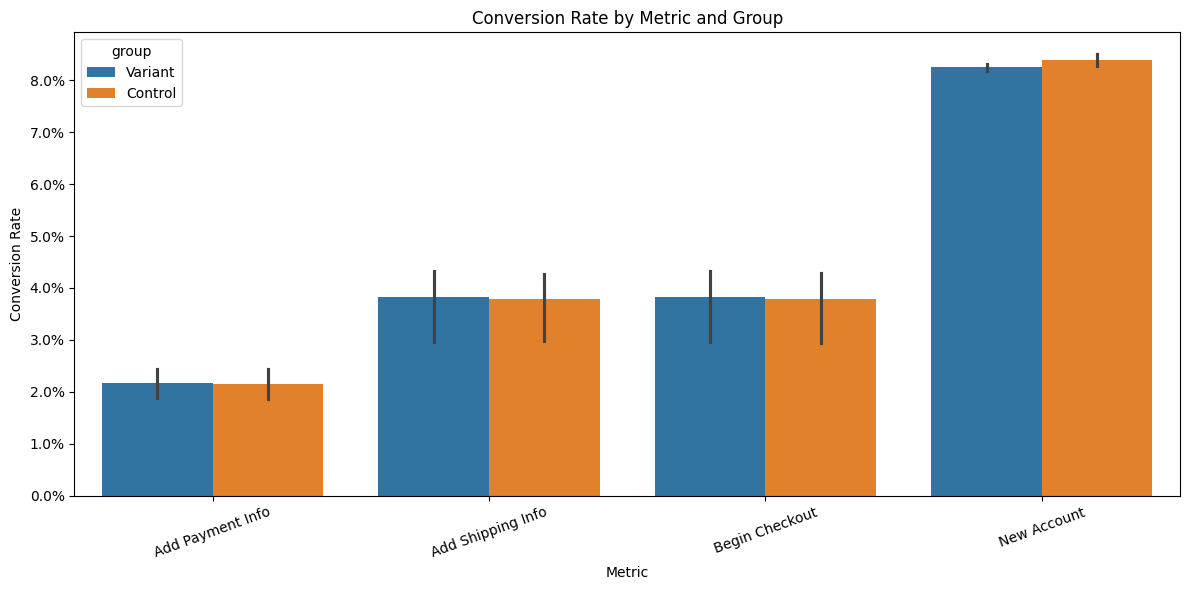

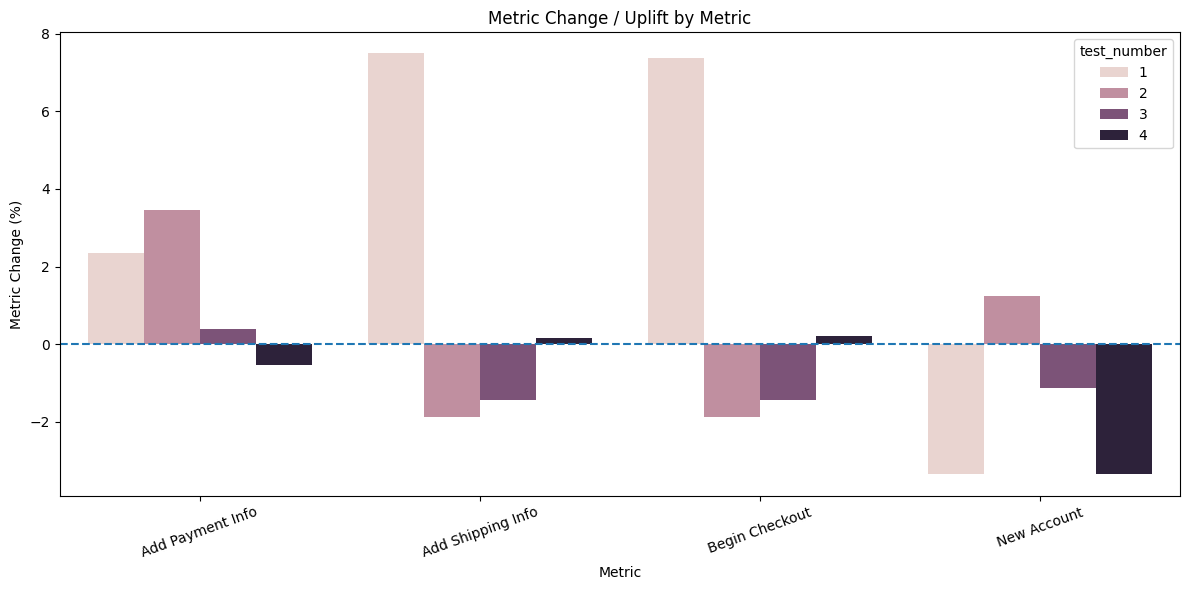

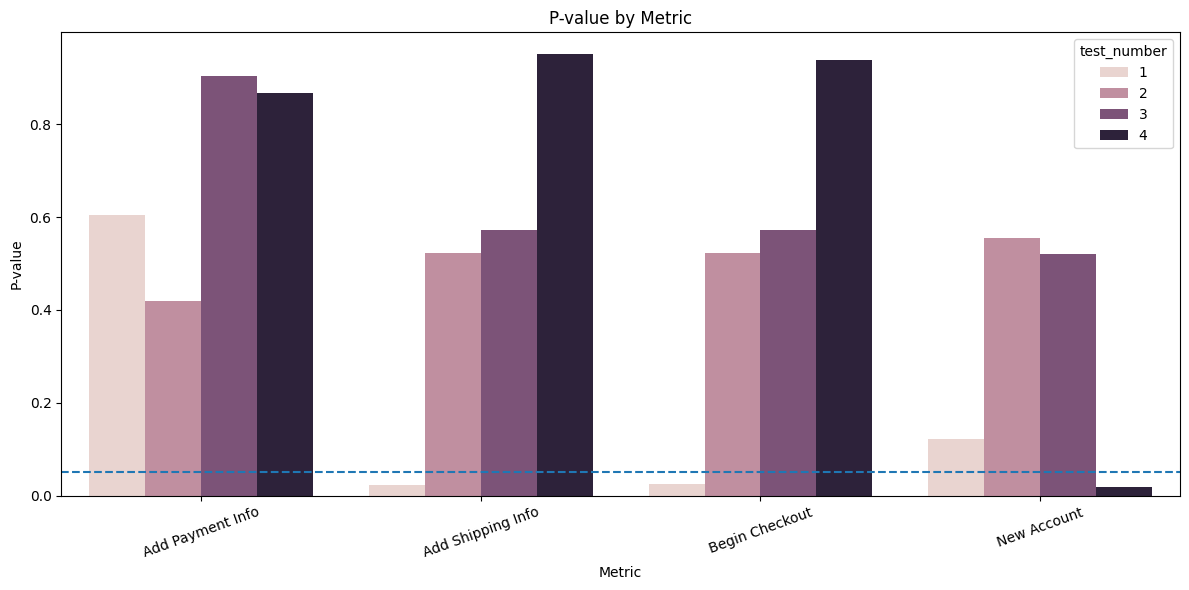

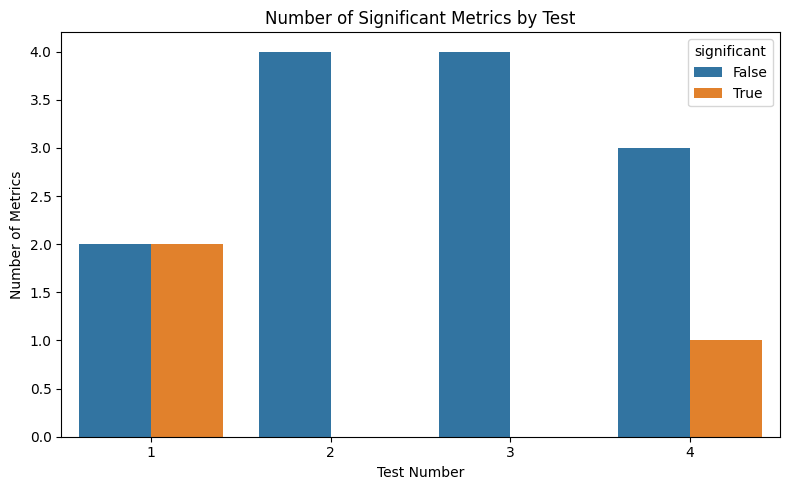

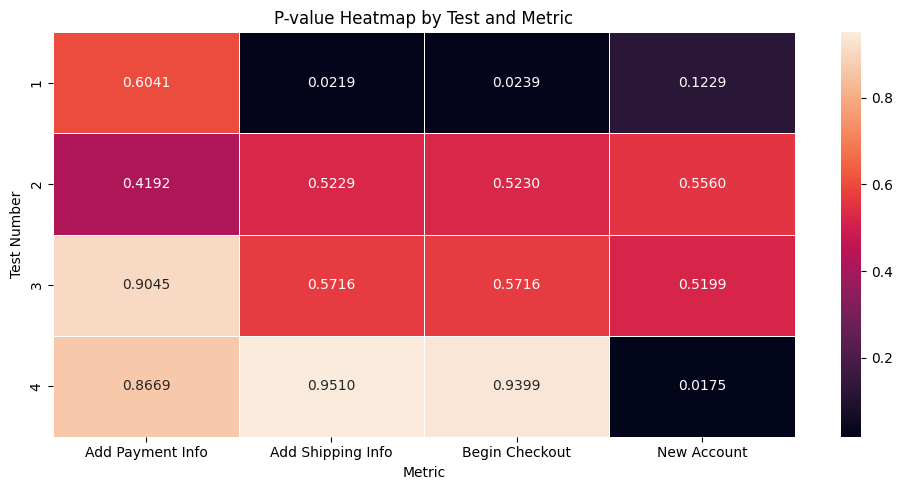

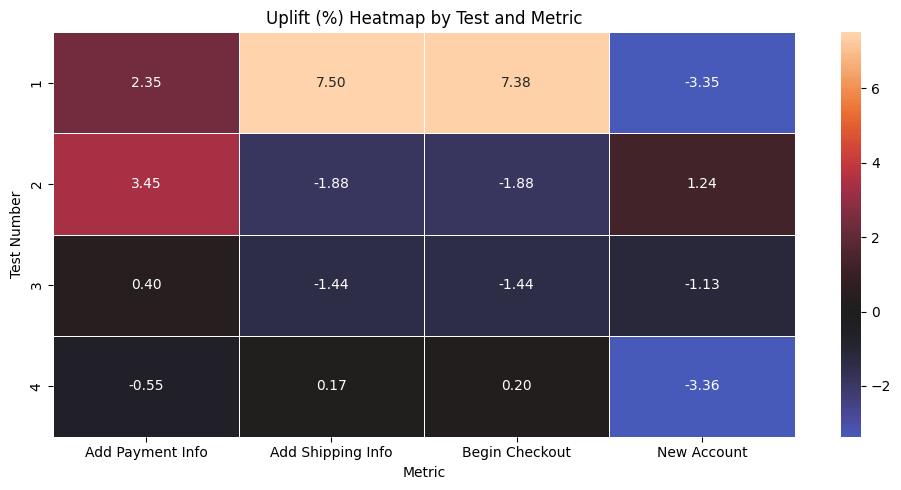

In [ ]:
# Sort results for cleaner charts
results_df = results_df.sort_values(['test_number', 'metric']).reset_index(drop=True)
# Create readable metric labels
metric_labels = {
    'add_payment_info': 'Add Payment Info',
    'add_shipping_info': 'Add Shipping Info',
    'begin_checkout': 'Begin Checkout',
    'new_account': 'New Account'
}
results_df['metric_label'] = results_df['metric'].map(metric_labels)
results_df.head()

# 1. Conversion Rate: Variant vs Control
conversion_plot_df = results_df.melt(
    id_vars=['test_number', 'metric_label'],
    value_vars=['conversion_rate_variant', 'conversion_rate_control'],
    var_name='group',
    value_name='conversion_rate'
)

conversion_plot_df['group'] = conversion_plot_df['group'].map({
    'conversion_rate_variant': 'Variant',
    'conversion_rate_control': 'Control'
})

plt.figure(figsize=(12, 6))

sns.barplot(
    data=conversion_plot_df,
    x='metric_label',
    y='conversion_rate',
    hue='group'
)

plt.title('Conversion Rate by Metric and Group')
plt.xlabel('Metric')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=20)
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.1%}')
)

plt.tight_layout()
plt.show()

# 2. Uplift / Metric Change (%)
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x='metric_label',
    y='metric_change',
    hue='test_number'
)

plt.axhline(0, linestyle='--')

plt.title('Metric Change / Uplift by Metric')
plt.xlabel('Metric')
plt.ylabel('Metric Change (%)')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# 3. P-value by Metric
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x='metric_label',
    y='p_value',
    hue='test_number'
)

plt.axhline(0.05, linestyle='--')

plt.title('P-value by Metric')
plt.xlabel('Metric')
plt.ylabel('P-value')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

#4. Statistical Significance Overview
significance_summary = (
    results_df
    .groupby(['test_number', 'significant'])
    .size()
    .reset_index(name='metric_count')
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=significance_summary,
    x='test_number',
    y='metric_count',
    hue='significant'
)

plt.title('Number of Significant Metrics by Test')
plt.xlabel('Test Number')
plt.ylabel('Number of Metrics')

plt.tight_layout()
plt.show()

# 5. Heatmap: P-values by Test and Metric
pvalue_pivot = results_df.pivot(
    index='test_number',
    columns='metric_label',
    values='p_value'
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    pvalue_pivot,
    annot=True,
    fmt='.4f',
    linewidths=0.5
)

plt.title('P-value Heatmap by Test and Metric')
plt.xlabel('Metric')
plt.ylabel('Test Number')

plt.tight_layout()
plt.show()

# 6. Heatmap: Uplift by Test and Metric

uplift_pivot = results_df.pivot(
    index='test_number',
    columns='metric_label',
    values='metric_change'
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    uplift_pivot,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    center=0
)

plt.title('Uplift (%) Heatmap by Test and Metric')
plt.xlabel('Metric')
plt.ylabel('Test Number')

plt.tight_layout()
plt.show()

## 5.10. Export final Excel file

The final Excel file will be used as a data source in Tableau.

In [ ]:
from google.colab import drive, files
!pip install openpyxl
import pandas as pd # Re-import pandas to ensure it picks up openpyxl

if not results_df.empty:

    # Mount Google Drive
    drive.mount('/content/drive')

    # Save a copy to Google Drive
    drive_output_path = '/content/drive/MyDrive/Mate_homework/ab_test_significance_results.xlsx'
    results_df.to_excel(drive_output_path, index=False)

    print(f'Excel saved to: {drive_output_path}')

else:
    print("final_results DataFrame is empty. Skipping export.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Excel saved to: /content/drive/MyDrive/Mate_homework/ab_test_significance_results.xlsx


# STAGE 2
#6. Tableau Dashboard Development, including:
##6.1 Dashboard redesign
##6.2 Visualization of conversion metrics
##6.3 Statistical significance indicators
##6.4 Interactive filtering
Tableau link: https://public.tableau.com/views/ABTestingStatisticalSignificanceAnalysis/ABTestingStatisticalSignificanceAnalysis?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

##6.5 Business interpretation

For metrics where:

significant = TRUE

the observed differences are unlikely to be caused by random variation.

This indicates that the tested change had a measurable impact on user behavior.

For example:

The Variant increased the Add Shipping Information conversion rate by 7.497% compared to the Control group. The result was statistically significant (p-value < 0.05), suggesting that the improvement was caused by the tested change rather than sampling variability.

Business recommendation:

Consider deploying the Variant to all users.
Continue monitoring long-term performance after rollout.
Validate that downstream business metrics also improve.

For metrics where:

significant = FALSE

there is insufficient statistical evidence to conclude that the Variant performs differently from the Control group.

Although some metrics may show positive uplift, the differences could be explained by random fluctuations in user behavior.

Example:

The Variant achieved a 2.352% the Add Payment increase in conversion rate; however, the p-value exceeded the significance threshold. Therefore, the observed uplift cannot be confidently attributed to the tested change.

#Business recommendation:

Do not make rollout decisions based solely on these results.
Consider extending the test duration.
Increase sample size in future experiments.
Investigate whether specific user segments react differently.

#Final Recommendation

Future experimentation programs should:

* Continue measuring statistical significance for all key conversion metrics.
* Validate results across user segments.
* Prioritize changes with both high uplift and statistical significance.
* Avoid implementing changes that show positive uplift but lack statistical evidence.
* Combine statistical results with business impact metrics when making product decisions.
This approach ensures that product improvements are supported by reliable data and contribute to sustainable business growth.